In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [4]:
df['Exited'].value_counts()

Exited
0    7964
1    2038
Name: count, dtype: int64

In [7]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df.dropna(inplace=True)
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.drop(['RowNumber', 'Surname'], axis=1, inplace=True)

In [11]:
df['Geography'].value_counts()

Geography
France     5012
Germany    2510
Spain      2476
Name: count, dtype: int64

In [12]:
df['Geography'] = df['Geography'].map({'France': 0, 'Spain': 1, 'Germany': 2})

In [13]:
df['Geography'].value_counts()

Geography
0    5012
2    2510
1    2476
Name: count, dtype: int64

In [16]:
df['Gender'] = df['Gender'].map({ 'Male': 0, 'Female': 1 })
df['Gender'].value_counts()

Gender
0    5455
1    4543
Name: count, dtype: int64

In [17]:
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,0,1,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,15647311,608,1,1,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,15619304,502,0,1,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,15701354,699,0,1,39.0,1,0.00,2,0.0,0.0,93826.63,0
5,15574012,645,1,0,44.0,8,113755.78,2,1.0,0.0,149756.71,1


C:\Users\Vinit Solanki\AppData\Local\Temp\ipykernel_12836\3231348619.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='Set1')


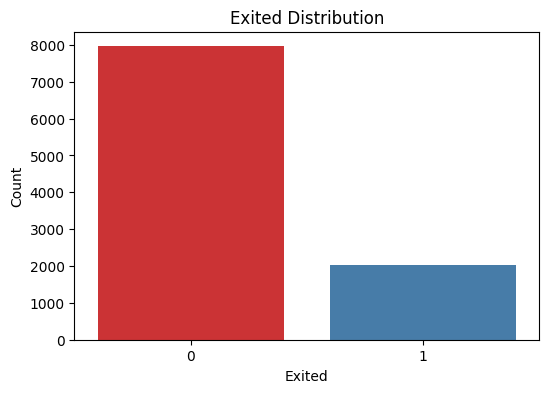

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, palette='Set1')
plt.title('Exited Distribution')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()

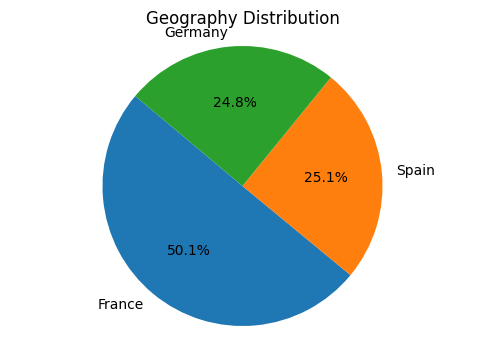

In [21]:
plt.figure(figsize=(6, 4))
plt.pie(df['Geography'].value_counts(), labels=['France', 'Spain', 'Germany'], autopct='%1.1f%%', startangle=140)
plt.title('Geography Distribution')
plt.axis('equal')
plt.show()

In [30]:
df['HasCrCard'] = df['HasCrCard'].astype(int)
df['Age'] = df['Age'].astype(int)
df['IsActiveMember'] = df['IsActiveMember'].astype(int)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9998 entries, 0 to 10001
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       9998 non-null   int64  
 1   CreditScore      9998 non-null   int64  
 2   Geography        9998 non-null   int64  
 3   Gender           9998 non-null   int64  
 4   Age              9998 non-null   int64  
 5   Tenure           9998 non-null   int64  
 6   Balance          9998 non-null   float64
 7   NumOfProducts    9998 non-null   int64  
 8   HasCrCard        9998 non-null   int64  
 9   IsActiveMember   9998 non-null   int64  
 10  EstimatedSalary  9998 non-null   float64
 11  Exited           9998 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 1015.4 KB


In [32]:
df.describe()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,9.998000e+03,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000
mean,1.569094e+07,650.529606,0.749750,0.454391,38.920184,5.013003,76481.490819,1.530206,0.705541,0.514803,100099.786455,0.203841
std,7.192399e+04,96.633003,0.830539,0.497940,10.488004,2.892152,62393.187035,0.581669,0.455822,0.499806,57510.939962,0.402872
min,1.556570e+07,350.000000,0.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.562854e+07,584.000000,0.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50983.750000,0.000000
50%,1.569073e+07,652.000000,0.000000,0.000000,37.000000,5.000000,97173.290000,1.000000,1.000000,1.000000,100218.210000,0.000000
75%,1.575323e+07,718.000000,2.000000,1.000000,44.000000,7.000000,127641.417500,2.000000,1.000000,1.000000,149395.882500,0.000000
max,1.581569e+07,850.000000,2.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [33]:
df.corr()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,1.000000,0.005542,0.000743,0.002365,0.009482,-0.014781,-0.012738,0.016979,-0.013742,0.001833,0.015175,-0.006262
CreditScore,0.005542,1.000000,0.008316,0.002730,-0.004235,0.000779,0.006580,0.012412,-0.005795,0.025125,-0.001256,-0.026790
Geography,0.000743,0.008316,1.000000,0.016420,0.048257,0.001313,0.348713,-0.005886,0.004033,-0.012522,0.007246,0.153964
Gender,0.002365,0.002730,0.016420,1.000000,0.027402,-0.014661,-0.012010,0.021853,-0.005850,-0.022408,0.007819,0.106186
Age,0.009482,-0.004235,0.048257,0.027402,1.000000,-0.010116,0.028379,-0.030759,-0.011717,0.085486,-0.006949,0.285452
Tenure,-0.014781,0.000779,0.001313,-0.014661,-0.010116,1.000000,-0.011986,0.013205,0.022557,-0.028090,0.007835,-0.014208
Balance,-0.012738,0.006580,0.348713,-0.012010,0.028379,-0.011986,1.000000,-0.304163,-0.014678,-0.010323,0.012637,0.118564
NumOfProducts,0.016979,0.012412,-0.005886,0.021853,-0.030759,0.013205,-0.304163,1.000000,0.003368,0.009644,0.014378,-0.047621
HasCrCard,-0.013742,-0.005795,0.004033,-0.005850,-0.011717,0.022557,-0.014678,0.003368,1.000000,-0.012039,-0.009924,-0.007023
IsActiveMember,0.001833,0.025125,-0.012522,-0.022408,0.085486,-0.028090,-0.010323,0.009644,-0.012039,1.000000,-0.011022,-0.156072


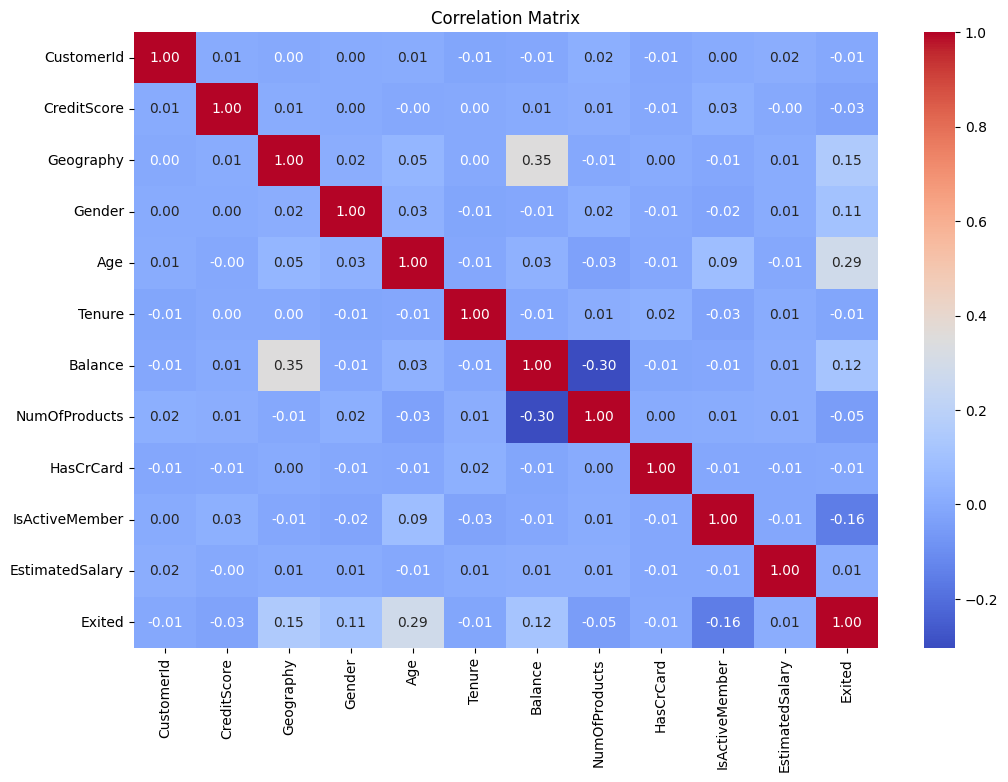

In [35]:
def checkMulticollinearity(df):
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', color="black")
    plt.title('Correlation Matrix')
    plt.show()

checkMulticollinearity(df)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [38]:
# Applying StandardScaler to the features
scaler = StandardScaler()
X = df.drop(['Exited'], axis=1)
y = df['Exited']
X_scaled = scaler.fit_transform(X)

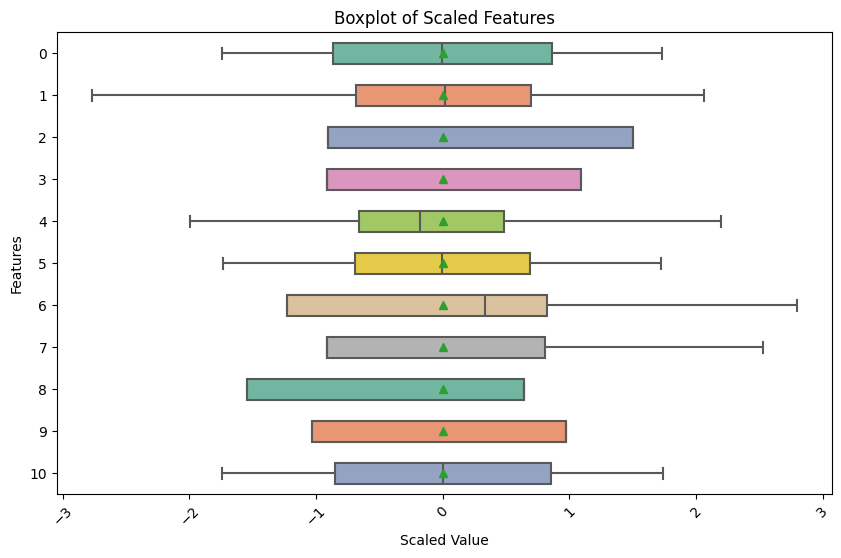

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=X_scaled, orient='h', palette='Set2', width=0.5, fliersize=0, linewidth=1.5, showfliers=False, showmeans=True)
plt.title('Boxplot of Scaled Features')
plt.xlabel('Scaled Value')
plt.ylabel('Features')
plt.xticks(rotation=45)
plt.show()

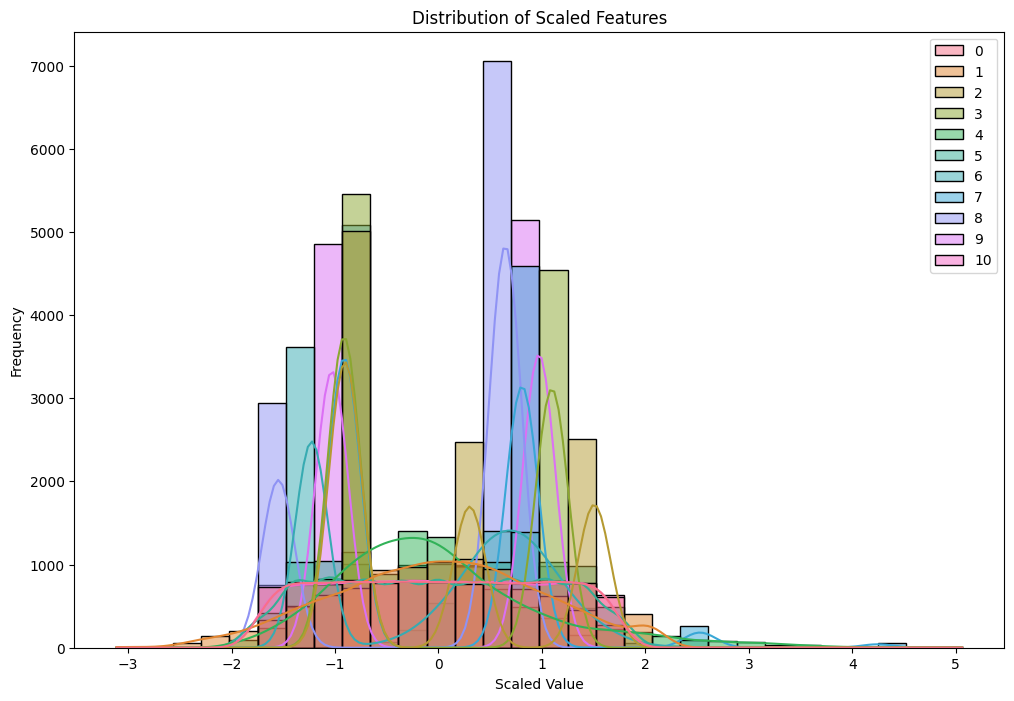

In [42]:
# Checking for normal distribution of features
plt.figure(figsize=(12, 8))
sns.histplot(data=X_scaled, kde=True, bins=30)
plt.title('Distribution of Scaled Features')
plt.xlabel('Scaled Value')
plt.ylabel('Frequency')
plt.show()

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [44]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7998, 11), (2000, 11), (7998,), (2000,))

In [45]:
# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print(classification_report(y_test, y_pred_log_reg))
print(confusion_matrix(y_test, y_pred_log_reg))

Logistic Regression Accuracy: 0.806
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1572
           1       0.65      0.20      0.30       428

    accuracy                           0.81      2000
   macro avg       0.74      0.58      0.60      2000
weighted avg       0.78      0.81      0.76      2000

[[1527   45]
 [ 343   85]]


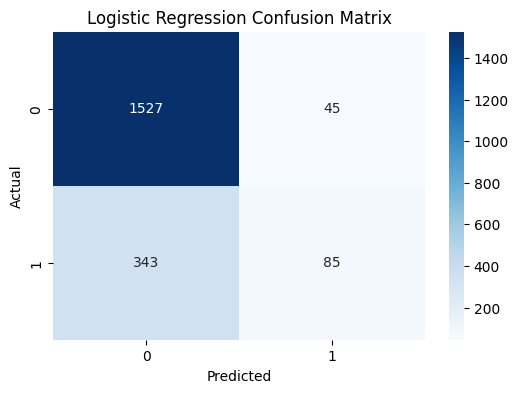

In [46]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log_reg), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [47]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8505
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1572
           1       0.75      0.45      0.56       428

    accuracy                           0.85      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000

[[1507   65]
 [ 234  194]]


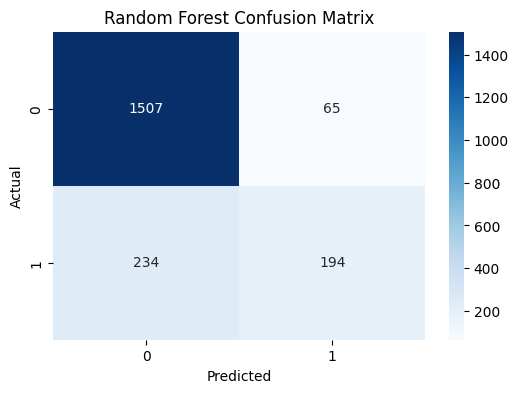

In [48]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [49]:
# Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7915
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1572
           1       0.51      0.49      0.50       428

    accuracy                           0.79      2000
   macro avg       0.69      0.68      0.68      2000
weighted avg       0.79      0.79      0.79      2000

[[1375  197]
 [ 220  208]]


In [50]:
# SVC
svc_clf = SVC(random_state=42)
svc_clf.fit(X_train, y_train)
y_pred_svc = svc_clf.predict(X_test)
print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))
print(confusion_matrix(y_test, y_pred_svc))

SVC Accuracy: 0.8475
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      1572
           1       0.82      0.37      0.51       428

    accuracy                           0.85      2000
   macro avg       0.83      0.67      0.71      2000
weighted avg       0.84      0.85      0.82      2000

[[1536   36]
 [ 269  159]]


In [51]:
# Hence Random Forest Classifier is the best model for this dataset with an accuracy of 86.5%
# Hyperparameter tuning for Random Forest Classifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

In [52]:
grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_clf, param_grid=grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


c:\Users\Vinit Solanki\OneDrive\Documents\ML&DS\myenv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
324 fits failed out of a total of 648.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
221 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Vinit Solanki\OneDrive\Documents\ML&DS\myenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Vinit Solanki\OneDrive\Documents\ML&DS\myenv\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\Vinit Solanki\OneDrive\Documents\ML&DS\myenv\Lib\site-packages\sklearn\base.py"

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             verbose=2)

In [53]:
grid_search.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [54]:
best_model = grid_search.best_estimator_

In [55]:
# Predicting with the best model
y_pred_best = best_model.predict(X_test)
print("Best Random Forest Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

Best Random Forest Accuracy: 0.855
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1572
           1       0.77      0.46      0.58       428

    accuracy                           0.85      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.85      0.84      2000

[[1512   60]
 [ 230  198]]


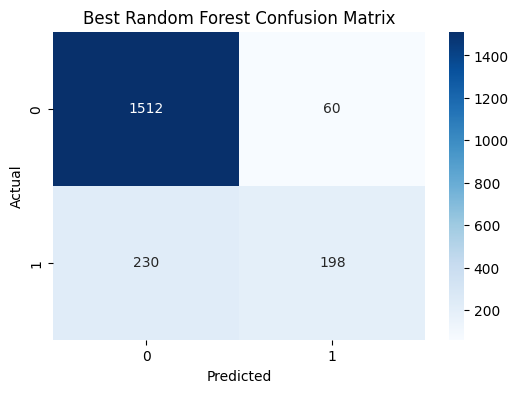

In [56]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title('Best Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [57]:
# Pickeling the model
import pickle
filename = 'best_random_forest_model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(best_model, file)